# House Sales in King County

**Submitted by:** Xiji Hang (MC646933).

**CISC7204 Data Science and Data Visualization — Assignment 01**

**Collaborators:** Xiji Hang (MC646933) and Xiaoyu Guo (MC648131). This laboratory is joint work throughout.

The required analysis follows the supplied course notebook. A separate extension examines the agreed research question. Reported results below are produced by the code in this notebook.

# Instructions


In this assignment, you are a Data Analyst working at a Real Estate Investment Trust. The Trust would like to start investing in Residential real estate. You are tasked with determining the market price of a house given a set of features. You will analyze and predict housing prices using attributes or features such as square footage, number of bedrooms, number of floors, and so on. This is a template notebook; your job is to complete the ten questions. Some hints to the questions are given.

As you are completing this notebook, take and save the **screenshots** of the final outputs of your solutions (e.g., final charts, tables, calculation results etc.). Share the evidence in the CISC7204 Module 06 personal forum and submit the notebook with its dataset through the designated Final Project assignment link in your class SUPPORT Moodle.


# About the Dataset

This dataset contains house sale prices for King County, which includes Seattle. It includes homes sold between May 2014 and May 2015. It was taken from [here](https://www.kaggle.com/harlfoxem/housesalesprediction?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-wwwcourseraorg-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2022-01-01). It was also slightly modified for the purposes of this course. 


| Variable      | Description                                                                                                 |
| ------------- | ----------------------------------------------------------------------------------------------------------- |
| id            | A notation for a house                                                                                      |
| date          | Date house was sold                                                                                         |
| price         | Price is prediction target                                                                                  |
| bedrooms      | Number of bedrooms                                                                                          |
| bathrooms     | Number of bathrooms                                                                                         |
| sqft_living   | Square footage of the home                                                                                  |
| sqft_lot      | Square footage of the lot                                                                                   |
| floors        | Total floors (levels) in house                                                                              |
| waterfront    | House which has a view to a waterfront                                                                      |
| view          | Supplied view code                                                                                             |
| condition     | How good the condition is overall                                                                           |
| grade         | overall grade given to the housing unit, based on King County grading system                                |
| sqft_above    | Square footage of house apart from basement                                                                 |
| sqft_basement | Square footage of the basement                                                                              |
| yr_built      | Built Year                                                                                                  |
| yr_renovated  | Year when house was renovated                                                                               |
| zipcode       | Zip code                                                                                                    |
| lat           | Latitude coordinate                                                                                         |
| long          | Longitude coordinate                                                                                        |
| sqft_living15 | Supplied comparison-area feature in square feet; retained as specified |
| sqft_lot15    | Supplied comparison-lot-area feature in square feet                                                            |


## **Import the required libraries**


In [1]:
# Figures use 300 DPI for readable high-resolution exports.
# Regression plots use seed=1 only for reproducible bootstrap confidence bands.
from pathlib import Path
import json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import (train_test_split, GroupShuffleSplit,
    GroupKFold, GridSearchCV)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import sklearn

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (7.2, 4.0), "figure.dpi": 300,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 12)
pd.set_option("display.precision", 4)
def locate_dataset(filename):
    # Accept a flat submission, the bundle root, or the notebooks subfolder.
    folders = (Path.cwd(), Path.cwd() / 'datasets' / 'raw',
               Path.cwd().parent / 'datasets' / 'raw')
    for folder in folders:
        candidate = folder / filename
        if candidate.is_file():
            return candidate.resolve()
    searched = ', '.join(str(folder / filename) for folder in folders)
    raise FileNotFoundError(f'Missing required dataset {filename}. Searched: {searched}')

def output_root_for(data_file):
    folder = data_file.resolve().parent
    if folder.name == 'raw' and folder.parent.name == 'datasets':
        return folder.parent.parent
    return folder

DATA_FILE = locate_dataset('kc_house_data_NaN.csv')
DATA = DATA_FILE.parent
OUTPUT_ROOT = output_root_for(DATA_FILE)
RESULTS = OUTPUT_ROOT / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
print(f"Python {platform.python_version()} | pandas {pd.__version__} | "
      f"scikit-learn {sklearn.__version__}")


Python 3.14.6 | pandas 3.0.3 | scikit-learn 1.9.0


# Module 1: Importing Data Sets


In [2]:
filepath = DATA / "kc_house_data_NaN.csv"
print(filepath.name)

kc_house_data_NaN.csv


Source: [IBM course King County CSV](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/FinalModule_Coursera/data/kc_house_data_NaN.csv), retrieved 15 September 2026. Normal local CSV loading replaces the browser-only download setup. The file has a header row.

In [3]:
df = pd.read_csv(filepath)
raw_housing = df.copy(deep=True)
print(f"Rows: {len(df):,}; columns: {df.shape[1]}")

Rows: 21,613; columns: 22


We use the method <code>head</code> to display the first 5 rows of the dataframe.


In [4]:
df.head()

,Unnamed: 0,id,date,price,bedrooms,bathrooms,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,...,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,...,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,...,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,20141209T000000,604000.0,4.0,3.00,...,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,20150218T000000,510000.0,3.0,2.00,...,0,98074,47.6168,-122.045,1800,7503


### Question 1

Display the data types of each column using the function dtypes. Take a screenshot of your code and output. You will need to submit the screenshot for the final project. 


In [5]:
display(df.dtypes.rename("Data type").to_frame())

,Data type
Unnamed: 0,int64
id,int64
date,str
price,float64
bedrooms,float64
bathrooms,float64
sqft_living,int64
sqft_lot,int64
floors,float64
waterfront,int64


We use the method describe to obtain a statistical summary of the dataframe.


In [6]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,21613.0,1.0806e+04,6.2393e+03,0.0000e+00,5.4030e+03,1.0806e+04,1.6209e+04,2.1612e+04
id,21613.0,4.5803e+09,2.8766e+09,1.0001e+06,2.1230e+09,3.9049e+09,7.3089e+09,9.9000e+09
price,21613.0,5.4009e+05,3.6713e+05,7.5000e+04,3.2195e+05,4.5000e+05,6.4500e+05,7.7000e+06
bedrooms,21600.0,3.3729e+00,9.2666e-01,1.0000e+00,3.0000e+00,3.0000e+00,4.0000e+00,3.3000e+01
bathrooms,21603.0,2.1157e+00,7.6900e-01,5.0000e-01,1.7500e+00,2.2500e+00,2.5000e+00,8.0000e+00
sqft_living,21613.0,2.0799e+03,9.1844e+02,2.9000e+02,1.4270e+03,1.9100e+03,2.5500e+03,1.3540e+04
sqft_lot,21613.0,1.5107e+04,4.1421e+04,5.2000e+02,5.0400e+03,7.6180e+03,1.0688e+04,1.6514e+06
floors,21613.0,1.4943e+00,5.3999e-01,1.0000e+00,1.0000e+00,1.5000e+00,2.0000e+00,3.5000e+00
waterfront,21613.0,7.5418e-03,8.6517e-02,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,1.0000e+00
view,21613.0,2.3430e-01,7.6632e-01,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,4.0000e+00


# Module 2: Data Wrangling


### Question 2

Drop the columns <code>"id"</code>  and <code>"Unnamed: 0"</code> from axis 1 using the method <code>drop()</code>, then use the method <code>describe()</code> to obtain a statistical summary of the data. Make sure the <code>inplace</code> parameter is set to <code>True</code>. Take a screenshot of your code and output. You will need to submit the screenshot for the final project. 


In [7]:
df.drop(["id","Unnamed: 0"],axis=1,inplace=True)
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
price,21613.0,540088.1418,367127.1965,75000.0000,321950.000,450000.0000,645000.000,7.7000e+06
bedrooms,21600.0,3.3729,0.9267,1.0000,3.000,3.0000,4.000,3.3000e+01
bathrooms,21603.0,2.1157,0.7690,0.5000,1.750,2.2500,2.500,8.0000e+00
sqft_living,21613.0,2079.8997,918.4409,290.0000,1427.000,1910.0000,2550.000,1.3540e+04
sqft_lot,21613.0,15106.9676,41420.5115,520.0000,5040.000,7618.0000,10688.000,1.6514e+06
floors,21613.0,1.4943,0.5400,1.0000,1.000,1.5000,2.000,3.5000e+00
waterfront,21613.0,0.0075,0.0865,0.0000,0.000,0.0000,0.000,1.0000e+00
view,21613.0,0.2343,0.7663,0.0000,0.000,0.0000,0.000,4.0000e+00
condition,21613.0,3.4094,0.6507,1.0000,3.000,3.0000,4.000,5.0000e+00
grade,21613.0,7.6569,1.1755,1.0000,7.000,7.0000,8.000,1.3000e+01


We can see we have missing values for the columns <code> bedrooms</code>  and <code> bathrooms </code>


In [8]:
print("number of NaN values for the column bedrooms :", df['bedrooms'].isnull().sum())
print("number of NaN values for the column bathrooms :", df['bathrooms'].isnull().sum())


number of NaN values for the column bedrooms : 13
number of NaN values for the column bathrooms : 10


We can replace the missing values of the column <code>'bedrooms'</code> with the mean of the column  <code>'bedrooms' </code> using the method <code>replace()</code>. Don't forget to set the <code>inplace</code> parameter to <code>True</code>


In [9]:
mean_bedrooms = df["bedrooms"].mean()
df["bedrooms"] = df["bedrooms"].fillna(mean_bedrooms)
print(f"Bedrooms mean used for filling: {mean_bedrooms:.4f}")

Bedrooms mean used for filling: 3.3729


We also replace the missing values of the column <code>'bathrooms'</code> with the mean of the column  <code>'bathrooms' </code> using the method <code>replace()</code>. Don't forget to set the <code> inplace </code>  parameter top <code> True </code>


In [10]:
mean_bathrooms = df["bathrooms"].mean()
df["bathrooms"] = df["bathrooms"].fillna(mean_bathrooms)
print(f"Bathrooms mean used for filling: {mean_bathrooms:.4f}")

Bathrooms mean used for filling: 2.1157


Direct assignment avoids chained-inplace behavior under pandas 3. These two mean imputations follow the teaching workflow; the extension estimates means on its training records only.

In [11]:
print("number of NaN values for the column bedrooms :", df['bedrooms'].isnull().sum())
print("number of NaN values for the column bathrooms :", df['bathrooms'].isnull().sum())

number of NaN values for the column bedrooms : 0
number of NaN values for the column bathrooms : 0


# Module 3: Exploratory Data Analysis


### Question 3

Use the method <code>value_counts</code> to count the number of houses with unique floor values, use the method <code>.to_frame()</code> to convert it to a data frame. Take a screenshot of your code and output. You will need to submit the screenshot for the final project. 


In [12]:
display(df["floors"].value_counts().to_frame(name="Number of houses"))

,Number of houses
floors,
1.0,10680
2.0,8241
1.5,1910
3.0,613
2.5,161
3.5,8


### Question 4

Use the function <code>boxplot</code> in the seaborn library  to  determine whether houses with a waterfront view or without a waterfront view have more price outliers. Take a screenshot of your code and boxplot. You will need to submit the screenshot for the final project. 


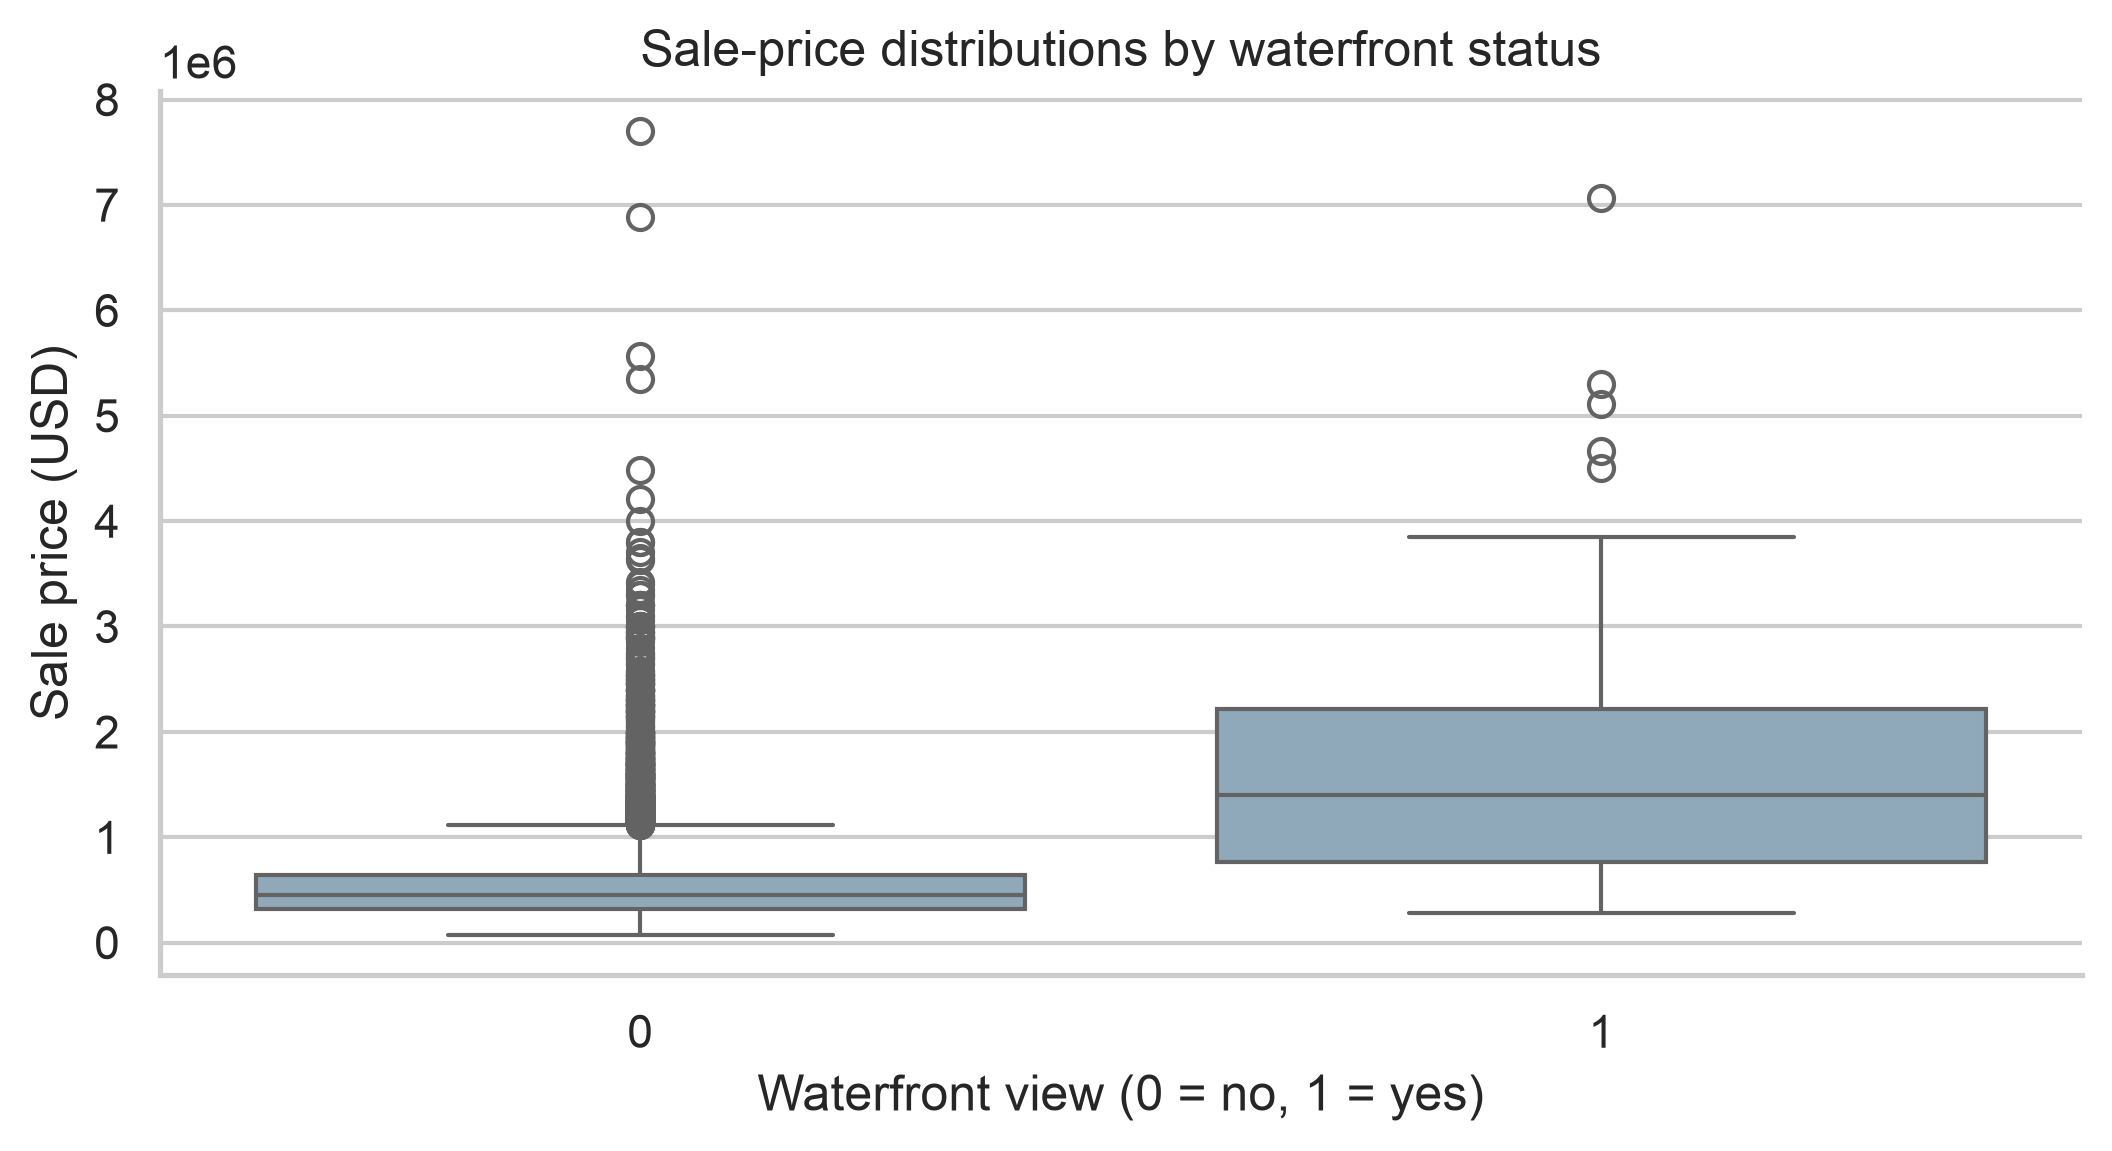

In [13]:
sns.boxplot(data=df,x="waterfront",y="price",color="#88abc1")
plt.xlabel("Waterfront view (0 = no, 1 = yes)");plt.ylabel("Sale price (USD)")
plt.title("Sale-price distributions by waterfront status")
plt.tight_layout();plt.show()

The outlier markers use each category’s own 1.5×IQR rule. A larger absolute count can reflect a much larger group, so counts and rates are checked below rather than equating the visual count with outlier probability.

In [14]:
outlier_rows=[]
for status,g in df.groupby("waterfront"):
    q1,q3=g["price"].quantile([.25,.75]); iqr=q3-q1
    n=int(((g["price"]<q1-1.5*iqr)|(g["price"]>q3+1.5*iqr)).sum())
    outlier_rows.append({"Waterfront":status,"Houses":len(g),"Outliers":n,
                         "Outlier share (%)":100*n/len(g)})
outliers=pd.DataFrame(outlier_rows).set_index("Waterfront")
display(outliers.round(2))
largest=outliers["Outliers"].idxmax()
display(Markdown(f"The {'non-waterfront' if largest==0 else 'waterfront'} group has more "
    "absolute outliers under the within-group boxplot rule. The percentages above "
    "separate this count comparison from the unequal group sizes."))

,Houses,Outliers,Outlier share (%)
Waterfront,,,
0,21450,1063,4.96
1,163,5,3.07


The non-waterfront group has more absolute outliers under the within-group boxplot rule. The percentages above separate this count comparison from the unequal group sizes.

### Question 5

Use the function <code>regplot</code>  in the seaborn library  to  determine if the feature <code>sqft_above</code> is negatively or positively correlated with price. Take a screenshot of your code and scatterplot. You will need to submit the screenshot for the final project. 


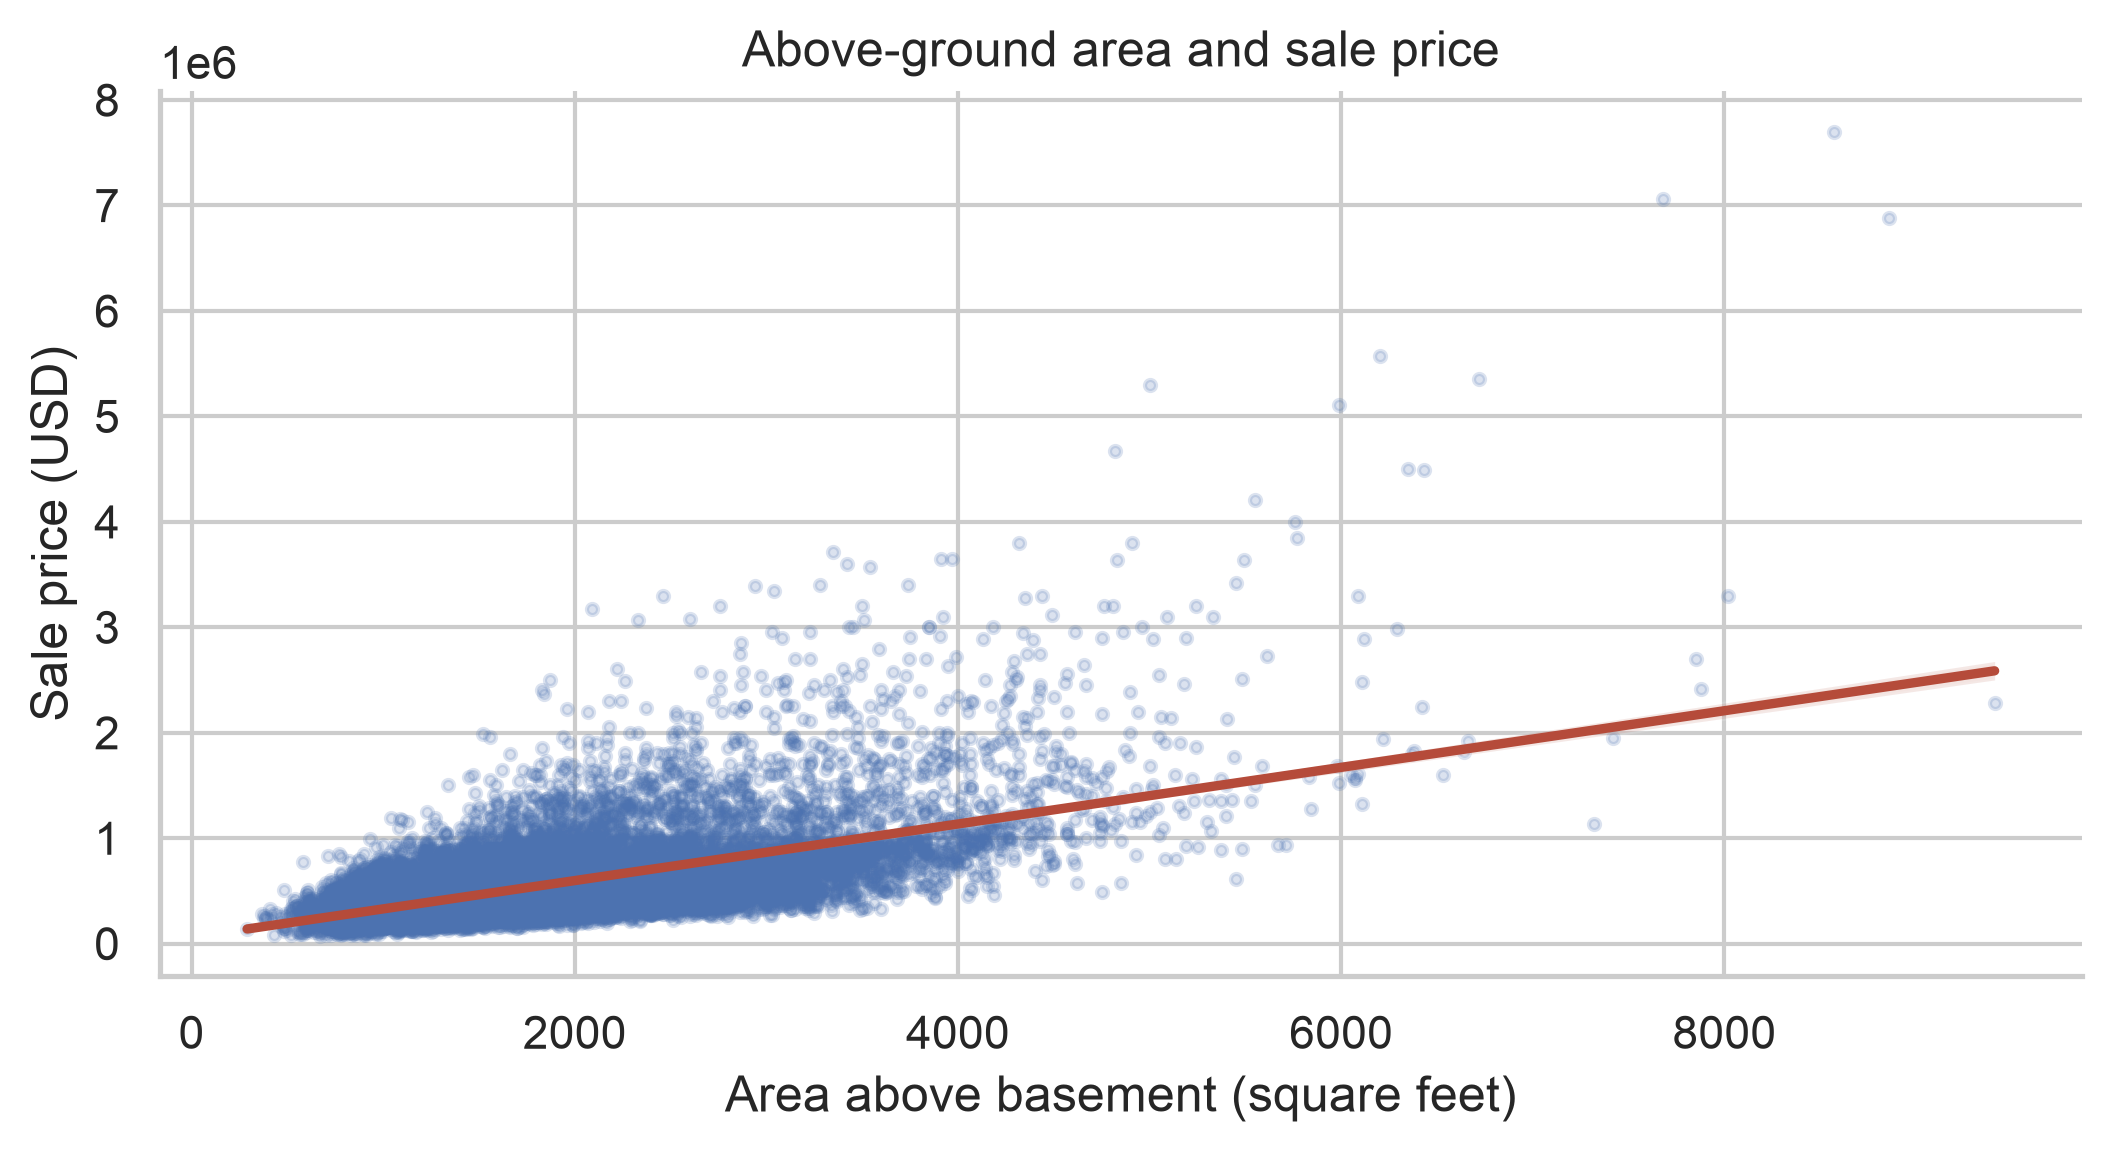

Pearson r: 0.6056


In [15]:
sns.regplot(seed=1, data=df,x="sqft_above",y="price",
    scatter_kws={"s":7,"alpha":.2},line_kws={"color":"#b54b3a"})
plt.xlabel("Area above basement (square feet)");plt.ylabel("Sale price (USD)")
plt.title("Above-ground area and sale price")
plt.tight_layout();plt.show()
print(f"Pearson r: {df['sqft_above'].corr(df['price']):.4f}")

We can use the Pandas method <code>corr()</code>  to find the feature other than price that is most correlated with price.


In [16]:
df_numeric = df.select_dtypes(include=[np.number])
df_numeric.corr()['price'].sort_values()

zipcode         -0.0532
long             0.0216
condition        0.0364
yr_built         0.0540
sqft_lot15       0.0824
sqft_lot         0.0897
yr_renovated     0.1264
floors           0.2568
waterfront       0.2664
lat              0.3070
bedrooms         0.3088
sqft_basement    0.3238
view             0.3973
bathrooms        0.5257
sqft_living15    0.5854
sqft_above       0.6056
grade            0.6674
sqft_living      0.7020
price            1.0000
Name: price, dtype: float64

# Module 4: Model Development


We can Fit a linear regression model using the  longitude feature <code>'long'</code> and  caculate the R^2.


In [17]:
X = df[['long']]
Y = df['price']
lm = LinearRegression()
lm.fit(X,Y)
lm.score(X, Y)

0.0004676943014898516

### Question  6

Fit a linear regression model to predict the <code>'price'</code> using the feature <code>'sqft_living'</code> then calculate the R^2. Take a screenshot of your code and the value of the R^2. You will need to submit it for the final project.


In [18]:
Y=df["price"]
lm_living=LinearRegression().fit(df[["sqft_living"]],Y)
housing_in_sample={"Living area only":lm_living.score(df[["sqft_living"]],Y)}
print(f"Living-area in-sample R²: {housing_in_sample['Living area only']:.4f}")

Living-area in-sample R²: 0.4929


### Question 7

Fit a linear regression model to predict the <code>'price'</code> using the list of features:


In [19]:
features =["floors", "waterfront","lat" ,"bedrooms" ,"sqft_basement" ,"view" ,"bathrooms","sqft_living15","sqft_above","grade","sqft_living"]     

Then calculate the R^2. Take a screenshot of your code and the value of the R^2. You will need to submit it for the final project.


In [20]:
mlr=LinearRegression().fit(df[features],Y)
housing_in_sample["Eleven-feature linear"]=mlr.score(df[features],Y)
print(f"Eleven-feature in-sample R²: {housing_in_sample['Eleven-feature linear']:.4f}")

Eleven-feature in-sample R²: 0.6577


### This will help with Question 8

Create a list of tuples, the first element in the tuple contains the name of the estimator:

<code>'scale'</code>

<code>'polynomial'</code>

<code>'model'</code>

The second element in the tuple  contains the model constructor

<code>StandardScaler()</code>

<code>PolynomialFeatures(include_bias=False)</code>

<code>LinearRegression()</code>


In [21]:
Input=[('scale',StandardScaler()),('polynomial', PolynomialFeatures(include_bias=False)),('model',LinearRegression())]

### Question 8

Use the list to create a pipeline object to predict the 'price', fit the object using the features in the list <code>features</code>, and calculate the R^2. Take a screenshot of your code and the value of the R^2. You will need to submit it for the final project.


In [22]:
pipe=Pipeline(Input).fit(df[features],Y)
housing_in_sample["Polynomial pipeline"]=pipe.score(df[features],Y)
display(pd.Series(housing_in_sample,name="In-sample R²").to_frame())

,In-sample R²
Living area only,0.4929
Eleven-feature linear,0.6577
Polynomial pipeline,0.7513


Q6–Q8 are in-sample fits. They cannot be ranked directly against the test scores in Q9–Q10 as if they used the same evaluation data.

# Module 5: Model Evaluation and Refinement


Import the necessary modules:


In [23]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
print("done")

done


We will split the data into training and testing sets:


In [24]:
features =["floors", "waterfront","lat" ,"bedrooms" ,"sqft_basement" ,"view" ,"bathrooms","sqft_living15","sqft_above","grade","sqft_living"]    
X = df[features]
Y = df['price']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=1)


print("number of test samples:", x_test.shape[0])
print("number of training samples:",x_train.shape[0])

number of test samples: 3242
number of training samples: 18371


### Question 9

Create and fit a Ridge regression object using the training data, set the regularization parameter to 0.1, and calculate the R^2 using the test data. Take a screenshot of your code and the value of the R^2. You will need to submit it for the final project.


In [25]:
from sklearn.linear_model import Ridge

In [26]:
ridge=Ridge(alpha=0.1).fit(x_train,y_train)
q9_r2=ridge.score(x_test,y_test)
print(f"Ridge alpha=0.1, test R²: {q9_r2:.4f}")

Ridge alpha=0.1, test R²: 0.6479


### Question 10

Perform a second order polynomial transform on both the training data and testing data. Create and fit a Ridge regression object using the training data, set the regularisation parameter to 0.1, and calculate the R^2 utilising the test data provided. Take a screenshot of your code and the R^2. You will need to submit it for the final project.


In [27]:
pr=PolynomialFeatures(degree=2)
x_train_pr=pr.fit_transform(x_train)
x_test_pr=pr.transform(x_test)
ridge_poly=Ridge(alpha=0.1).fit(x_train_pr,y_train)
q10_r2=ridge_poly.score(x_test_pr,y_test)
print(f"Degree-2 Ridge alpha=0.1, test R²: {q10_r2:.4f}")

Degree-2 Ridge alpha=0.1, test R²: 0.7003


Q9–Q10 follow the prescribed 15% holdout with seed 1 and alpha 0.1. Full-data imputation and repeated house IDs limit this teaching split as a strict generalization test. The extension rebuilds preprocessing from the original input and handles overlapping IDs.

<h2>About the Authors:</h2> 

<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2022-01-01">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


Other contributors: <a href="https://www.linkedin.com/in/michelleccarey/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2022-01-01">Michelle Carey</a>, <a href="https://www.linkedin.com/in/jiahui-mavis-zhou-a4537814a?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2022-01-01">Mavis Zhou</a>



## <h3 align="center"> © IBM Corporation 2020. All rights reserved. <h3/>
<!--## Change Log

| Date (YYYY-MM-DD) | Version | Changed By      | Change Description                           |
| ----------------- | ------- | --------------- | -------------------------------------------- |
| 2020-12-01        | 2.2     | Aije Egwaikhide | Coverted Data describtion from text to table |
| 2020-10-06        | 2.1     | Lakshmi Holla   | Changed markdown instruction of Question1    |
| 2020-08-27        | 2.0     | Malika Singla   | Added lab to GitLab                          |
| 2022-06-13        | 2.3     | Svitlana Kramar | Updated Notebook sharing instructions        |
| <hr>              |         |                 |                                              |


--!>
<p>


## Extension — Random and later-sales validation

A random holdout mixes dates, whereas a chronological holdout asks how a fixed model performs on later sales. Both comparisons below use the same eleven features, degree-2 Ridge model with alpha 0.1, and training-only imputation/scaling. House IDs appearing in a test set are removed from its training set. Test metrics are not used to change the model.


In [28]:
raw=raw_housing.copy()
raw["sale_date"]=pd.to_datetime(raw["date"],format="%Y%m%dT%H%M%S")
assert raw["price"].notna().all()
print(f"Records: {len(raw):,}; additional sale records sharing an existing house ID: {raw['id'].duplicated().sum()}")
print(f"Sales dates: {raw.sale_date.min().date()} to {raw.sale_date.max().date()}")
all_idx=np.arange(len(raw))
r_train,r_test=train_test_split(all_idx,test_size=.15,random_state=1)
ordered=raw.sort_values(["sale_date","id"]).index.to_numpy()
boundary=raw.loc[ordered[int(len(ordered)*.85)],"sale_date"]
t_train=raw.index[raw.sale_date<boundary].to_numpy()
t_test=raw.index[raw.sale_date>=boundary].to_numpy()
split_info={}; eval_splits={}
for name,(train,test) in {"Random":(r_train,r_test),
                         "Later sales":(t_train,t_test)}.items():
    overlap=raw.loc[train,"id"].isin(raw.loc[test,"id"])
    clean_train=train[~overlap.to_numpy()]
    assert not set(raw.loc[clean_train,"id"]) & set(raw.loc[test,"id"])
    eval_splits[name]=(clean_train,test)
    split_info[name]={"Train records":len(clean_train),"Test records":len(test),
        "Purged train records":int(overlap.sum()),
        "Test start":str(raw.loc[test,"sale_date"].min().date()),
        "Test end":str(raw.loc[test,"sale_date"].max().date())}
display(pd.DataFrame(split_info).T)

Records: 21,613; additional sale records sharing an existing house ID: 177
Sales dates: 2014-05-02 to 2015-05-27


,Train records,Test records,Purged train records,Test start,Test end
Random,18333,3242,38,2014-05-02,2015-05-15
Later sales,18277,3271,65,2015-03-26,2015-05-27


In [29]:
def housing_pipeline():
    return Pipeline([("impute",SimpleImputer(strategy="mean")),
        ("scale",StandardScaler()),
        ("poly",PolynomialFeatures(degree=2,include_bias=False)),
        ("ridge",Ridge(alpha=.1))])
housing_rows=[];housing_predictions={}
for name,(train,test) in eval_splits.items():
    model=housing_pipeline().fit(raw.loc[train,features],raw.loc[train,"price"])
    pred=model.predict(raw.loc[test,features])
    assert np.isfinite(pred).all()
    housing_predictions[name]=pred
    actual=raw.loc[test,"price"]
    housing_rows.append({"Split":name,"R²":r2_score(actual,pred),
        "MAE (USD)":mean_absolute_error(actual,pred),
        "RMSE (USD)":mean_squared_error(actual,pred)**.5,
        "Median test price (USD)":actual.median(),
        "Negative predictions":int((pred<0).sum())})
housing_results=pd.DataFrame(housing_rows).set_index("Split")
display(housing_results.round(3))
housing_results.to_csv(RESULTS/"housing_extension_metrics.csv")

,R²,MAE (USD),RMSE (USD),Median test price (USD),Negative predictions
Split,,,,,
Random,0.712,118481.942,205753.695,450000.0,2
Later sales,0.715,120302.818,201170.493,470500.0,1


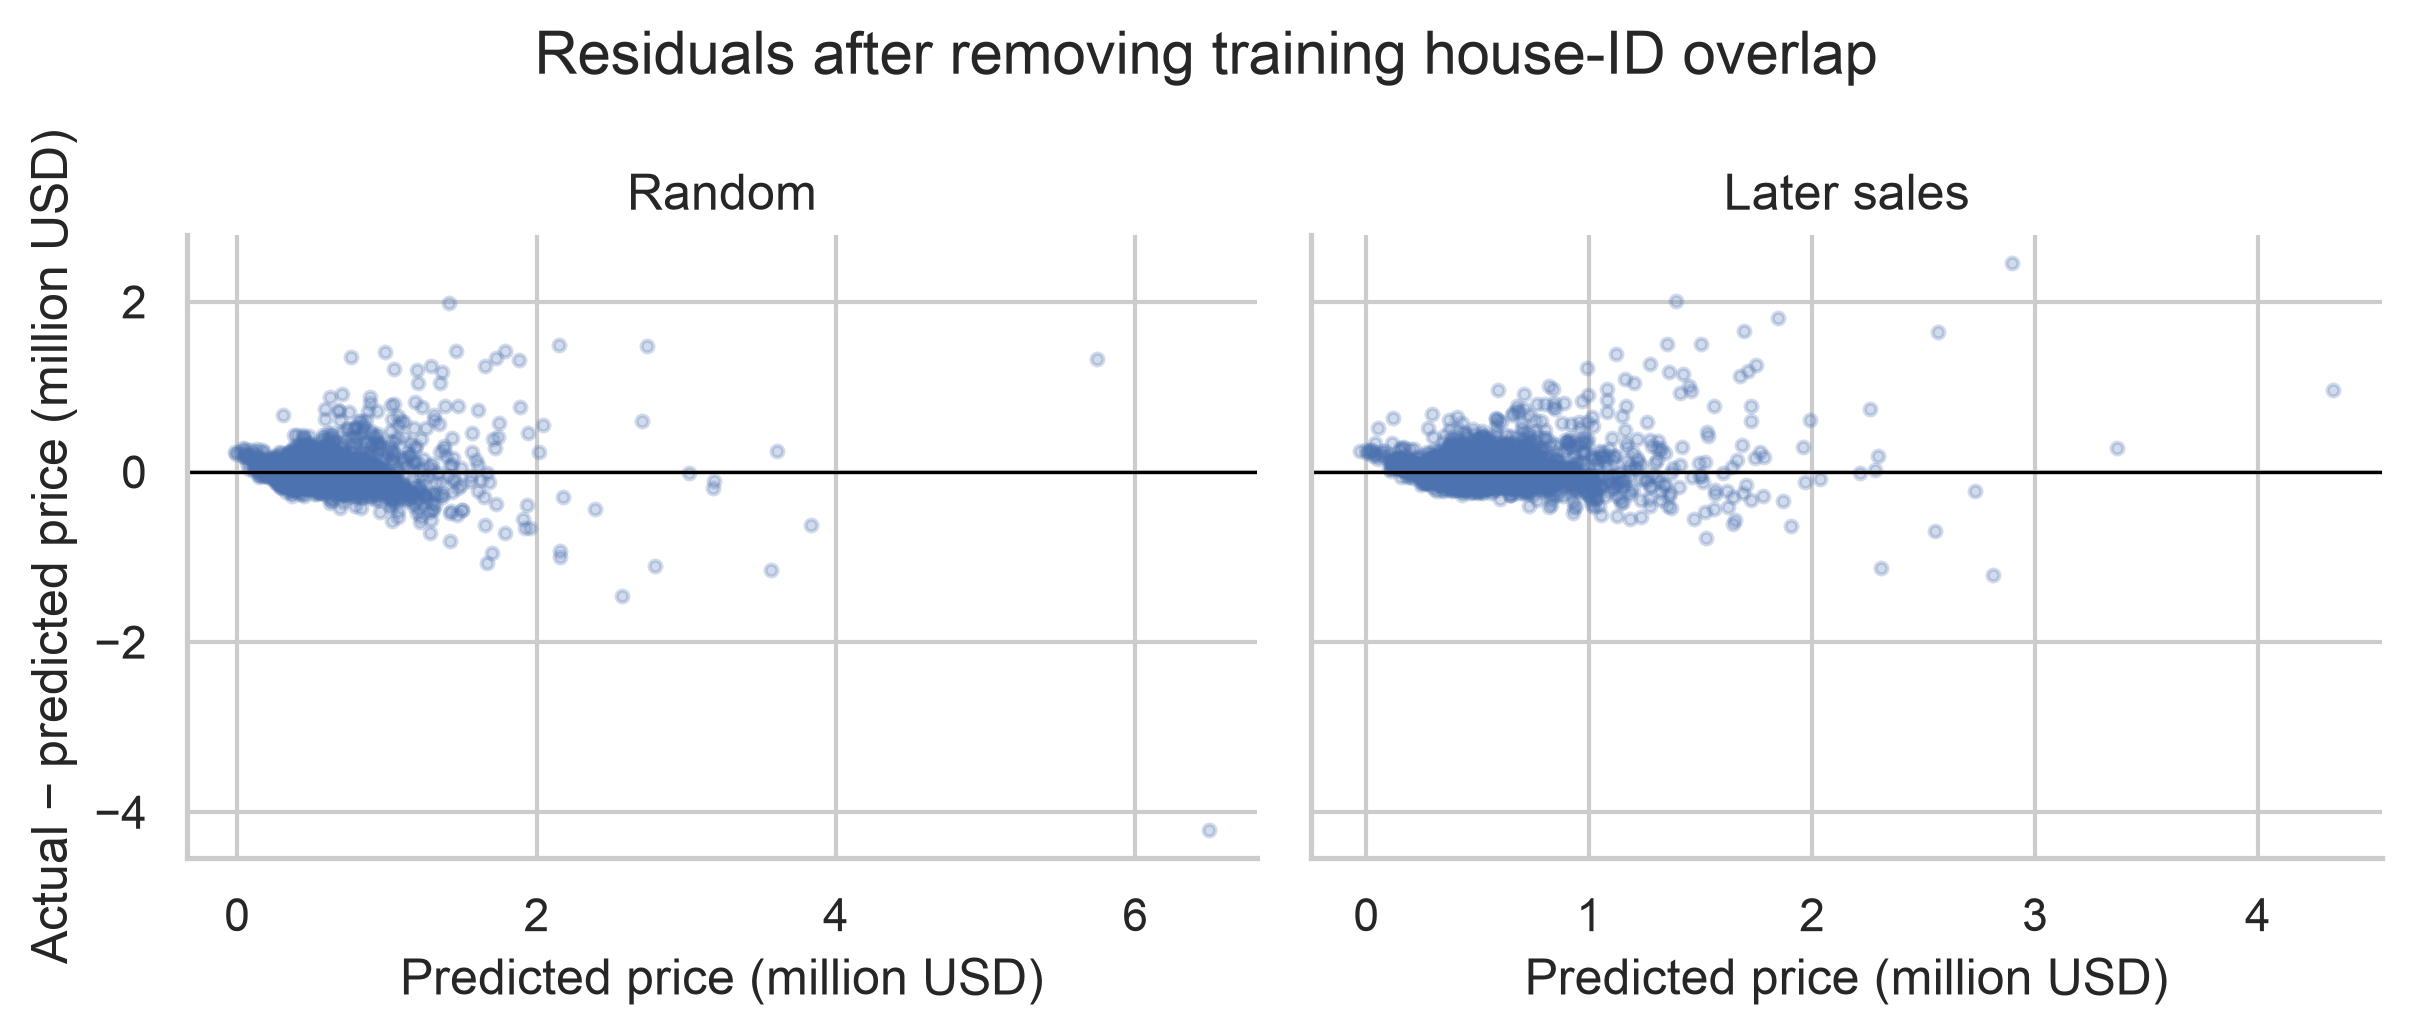

In [30]:
fig,axes=plt.subplots(1,2,figsize=(8.2,3.5),sharey=True)
for ax,(name,(train,test)) in zip(axes,eval_splits.items()):
    actual=raw.loc[test,"price"];pred=housing_predictions[name]
    ax.scatter(pred/1e6,(actual-pred)/1e6,s=8,alpha=.25)
    ax.axhline(0,color="black",linewidth=.8)
    ax.set(title=name,xlabel="Predicted price (million USD)")
axes[0].set_ylabel("Actual − predicted price (million USD)")
fig.suptitle("Residuals after removing training house-ID overlap")
fig.tight_layout();plt.show()

In [31]:
a=housing_results.loc["Random"];b=housing_results.loc["Later sales"]
display(Markdown(
    f"The fixed model has RMSE **USD {a['RMSE (USD)']:,.0f}** under random validation "
    f"and **USD {b['RMSE (USD)']:,.0f}** for later sales. Corresponding R² values are "
    f"**{a['R²']:.3f}** and **{b['R²']:.3f}**. Median test prices are "
    f"**USD {a['Median test price (USD)']:,.0f}** and "
    f"**USD {b['Median test price (USD)']:,.0f}**, respectively. The test populations "
    "and training compositions differ, so the score difference measures sensitivity "
    "to the evaluation design rather than the isolated effect of time. "
    f"Later-sales MAE is higher (**USD {b['MAE (USD)']:,.0f}** versus "
    f"**USD {a['MAE (USD)']:,.0f}**), so the metrics do not show a uniform improvement."))

The fixed model has RMSE **USD 205,754** under random validation and **USD 201,170** for later sales. Corresponding R² values are **0.712** and **0.715**. Median test prices are **USD 450,000** and **USD 470,500**, respectively. The test populations and training compositions differ, so the score difference measures sensitivity to the evaluation design rather than the isolated effect of time. Later-sales MAE is higher (**USD 120,303** versus **USD 118,482**), so the metrics do not show a uniform improvement.

The date boundary includes every sale on the boundary date in the test set. Removing house-ID overlap tests transfer to other houses in the held-out records; it does not remove neighbourhood dependence. A single historical period from May 2014 to May 2015 cannot establish robustness to present-day prices, longer economic cycles, or other cities.

## Acknowledgement

The laboratory template and teaching examples are adapted from IBM Skills Network materials supplied through CISC7204. [OpenAI Codex](https://openai.com/codex/) assisted with code implementation, compatibility fixes, debugging and the wording of explanations. Numerical results were generated by executing this notebook; both collaborators are responsible for reviewing the work before submission.
